In [93]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



## PCA analysis

In [116]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True, return_v_unit=False):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[item_ids].copy()
		b_math = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)
		if return_v_unit:
			return v_unit

	else: 
		print("Used pre-computed direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	math_scores = theta_matrix.dot(v_unit)

	return pd.Series(math_scores, index=theta_df.index, name="ability")


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


def compute_pca(theta_df, a_df, item_ids, adjust_difficulty=True,
                     return_mean_vector=False, variance_threshold=0.8, b_series=None, save_path='../result/PCA_explained.pdf',
                     num_pcs=None):
    """
    Compute math-specific ability dimensions using PCA on discrimination vectors,
    and plot explained variance with threshold.
    
    Args:
        theta_df (pd.DataFrame): Factor scores (models/test-takers x factors)
        a_df (pd.DataFrame): Discrimination parameters (items x factors)
        item_ids (list): List of item IDs considered
        adjust_difficulty (bool): Weight items by difficulty if desired
        return_mean_vector (bool): Also compute the mean-based math vector for comparison
        variance_threshold (float): Cumulative explained variance threshold for selecting PCs
        b_series (pd.Series, optional): Item difficulty for weighting
        
    Returns:
        dict:
            'pca_vectors': numpy array (unit vectors of PCs)
            'pca_loadings': pandas DataFrame of factor loadings per PC
            'mean_vector': numpy array (unit vector of mean, optional)
            'scalar_scores': pd.DataFrame of projected scores for each PC
            'explained_variance': array of variance explained per PC
            'num_pcs_above_threshold': int, number of PCs needed to reach cumulative threshold
    """
    # 1. Extract item discriminations
    A_math = a_df.loc[item_ids].copy()

    print(A_math.shape)
    
    # 2. Optional: adjust by difficulty
    if adjust_difficulty and b_series is not None:
        b_math = b_series.loc[item_ids]
        weights = 1 / (1 + np.abs(b_math.values))
        A_math = A_math.multiply(weights, axis=0)

    # 3. Fit PCA on all math items
    if num_pcs is None:
        pca = PCA()
        pca.fit(A_math.values)
    else:
        pca = PCA(n_components=num_pcs)
        pca.fit(A_math.values)
        
    pca_vectors = pca.components_  # shape: n_pcs x n_factors
    # Normalize each PC to unit vector
    pca_vectors = np.array([v / np.linalg.norm(v) for v in pca_vectors])
    
    # 4. Compute factor loadings per PC
    # Loading of PC on original factor = eigenvector * sqrt(eigenvalue)
    pca_loadings = pd.DataFrame(
        pca_vectors.T * np.sqrt(pca.explained_variance_),
        index=A_math.columns,
        columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
    )
    
    item_loadings = pd.DataFrame(
		A_math.values.dot(pca_vectors.T),
		index=A_math.index,
		columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
	)

    print(A_math.values.dot(pca_vectors.T).shape)
    print(pca_vectors.T.shape)
    
    # 5. Optional: compute mean vector for comparison
    v_mean = None
    if return_mean_vector:
        v_mean = A_math.mean(axis=0).values
        v_mean /= np.linalg.norm(v_mean)
    
    # 6. Project theta onto all PCs
    scalar_scores = pd.DataFrame(theta_df.values.dot(pca_vectors.T),
                                 index=theta_df.index,
                                 columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])])
    
    # 7. Compute cumulative variance and threshold
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    num_pcs_above_threshold = np.searchsorted(cumulative_variance, variance_threshold) + 1
    # 8. Plot explained variance and cumulative variance
    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual PC')
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, color='firebrick', marker='o', label='Cumulative')
    plt.axhline(y=variance_threshold, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.xticks(range(1, len(explained_variance)+1, 2))
    plt.xlabel('PC')
    plt.ylabel('Variance')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    return {
        'pca_vectors': pca_vectors,
        'pca_loadings': pca_loadings,
        'item_loadings': item_loadings,
        'mean_vector': v_mean,
        'scalar_scores': scalar_scores,
        'explained_variance': explained_variance,
        'num_pcs_above_threshold': num_pcs_above_threshold
    }

(1435, 19)
(1435, 19)
(19, 19)


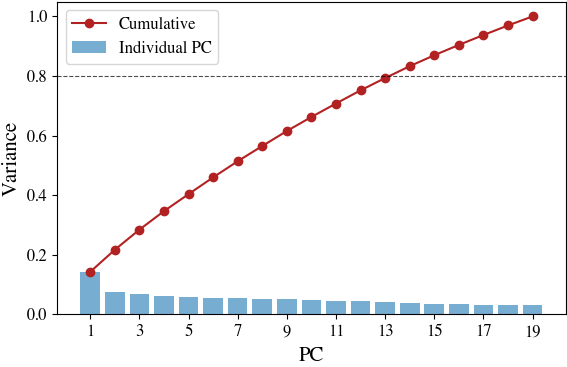

14


In [ ]:
conv_dataset = ['math', 'gsm']

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

pd.DataFrame(scenario_questions, columns=['question']).to_pickle('../result/math_scenario_questions.pkl')

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

result = compute_pca(theta_df, a_df, scenario_questions, return_mean_vector=True, save_path='../result/PCA_explained_med_qa.pdf')
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']
print(num_pcs)

In [91]:
math_scores = compute_scalar_ability(theta_df, a_df_math, b_series, scenario_questions)
math_scores_pca = compute_scalar_ability(theta_df, a_df_math, b_series, scenario_questions, -v_pca[2])

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
pca_convergent_corr = math_scores_pca.corr(conv_benchmark_scores, method='spearman')
mean_convergent_corr = math_scores.corr(conv_benchmark_scores, method='spearman')
print('pca_convergent_corr', pca_convergent_corr)
print('mean_convergent_corr', mean_convergent_corr)

div_benchmark_scores = resmat[resmat.columns[~resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
mean_divergent_corr = math_scores.corr(div_benchmark_scores, method='spearman')
print('mean_divergent_corr', mean_divergent_corr)

Mean unit vector:  [-0.21494706 -0.22744916 -0.23566988 -0.1679211  -0.3850087  -0.2394518
  0.04993943  0.25944665 -0.39451882 -0.04396391 -0.01316161 -0.33871678
  0.30975133  0.06780565  0.26811373 -0.26613766  0.13065511 -0.04555357
 -0.08982014]
Used pre-computed math direction vector. [ 0.09806305 -0.0161145   0.02566628  0.35919338  0.0207698  -0.01542718
 -0.17195374 -0.5778991  -0.12093493 -0.20871843 -0.07599292  0.26798984
  0.25664496 -0.2714601  -0.34177804  0.07735477  0.14787374  0.01404564
 -0.2757557 ]
pca_convergent_corr -0.7094924689047569
mean_convergent_corr 0.9579346783771242
mean_divergent_corr 0.5965356809975485


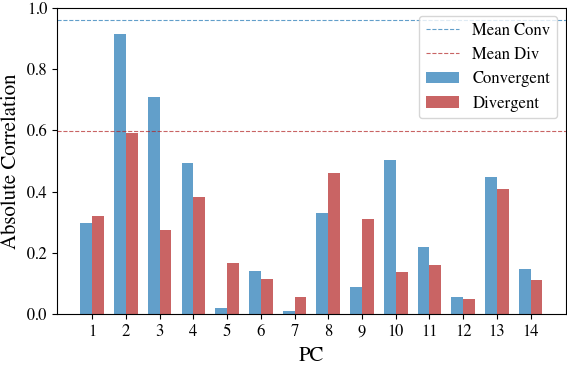

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(num_pcs)]
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=abs(mean_convergent_corr), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=abs(mean_divergent_corr), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in range(num_pcs)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/pc_correlations_histogram_{"".join(conv_dataset)}.pdf')
plt.show()

In [84]:
import pandas as pd
import numpy as np

def get_reference_composite_eigenvector(a_df: pd.DataFrame) -> np.ndarray:
    """
    Calculates the eigenvector for the reference composite from a matrix of 
    multidimensional discrimination parameters.

    This vector corresponds to the largest eigenvalue of the a'a matrix and 
    represents the direction of the dominant unidimensional scale in the 
    multidimensional space.

    Args:
        a_df: A pandas DataFrame with shape (n_items, n_dimensions) 
              containing the 'a' parameters.

    Returns:
        A NumPy array representing the eigenvector of the reference composite.
    """
    # Convert the DataFrame to a NumPy array for matrix operations
    a_matrix = a_df.to_numpy()
    
    # Calculate the a-transpose-a matrix (a'a)
    a_t_a = a_matrix.T @ a_matrix
    
    # Calculate the eigenvalues and eigenvectors of the a'a matrix
    eigenvalues, eigenvectors = np.linalg.eig(a_t_a)
    
    # Find the index of the largest eigenvalue
    max_eigenvalue_index = np.argmax(eigenvalues)
    
    # Select the corresponding eigenvector
    reference_composite_vector = eigenvectors[:, max_eigenvalue_index]
    
    return reference_composite_vector

In [85]:
defined_PCs = {
  "Multi-Step Quantitative Reasoning": 1,
  "Application of Formal Mathematical Concepts": 2,
  "Direct Translation to Computation": 3,
  "Procedural and Abstract Algebra": 4,
  "Algebraic Word Problem Formulation": 5,
  "Sequential Calculation with State-Tracking": 6,
  "Application of Ratios, Rates, and Proportions": 7,
  "Complex Integrated Problem Solving": 8,
}

sub_abilities = {
  "Chained Reasoning": [1, 8],
  "State Tracking": [6],
  "Ratios, Rates, and Proportions": [7],
  "Calculation": [4],
  "Fundamental Principles": [2],
  "Word Problem": [3],
  "Algebric Formulation": [5],
}

In [86]:
df_result = pd.read_pickle('../result/content_validation_res.pkl')
df_result = df_result[~df_result['skill'].str.contains("ERROR:")]
df_result['PC'] = df_result['skill'].map(defined_PCs)
df_result['sub_ability'] = df_result['PC'].apply(lambda x: ''.join([k for k, v in sub_abilities.items() if x in v]) if x else None)
print(df_result['PC'].value_counts())
df_result.drop(columns=['skill', 'rationale', 'PC'], inplace=True)

PC
3    881
2    158
6    110
1     84
7     69
5     68
4     57
8      4
Name: count, dtype: int64


In [87]:
  # "Chained Reasoning": [1, 8],
  # "State Tracking": [6],
  # "Ratios, Rates, and Proportions": [7],
  # "Calculation": [4],
  # "Fundamental Principles": [2],
  # "Word Problem": [3],
  # "Algebric Formulation": [5],
extracted_questions_1 = df_result[df_result['sub_ability'] == 'Chained Reasoning']['question'].to_list()
extracted_questions_2 = df_result[df_result['sub_ability'] == 'State Tracking']['question'].to_list()
extracted_questions_3 = df_result[df_result['sub_ability'] == 'Ratios, Rates, and Proportions']['question'].to_list()
extracted_questions_4 = df_result[df_result['sub_ability'] == 'Calculation']['question'].to_list()
extracted_questions_5 = df_result[df_result['sub_ability'] == 'Fundamental Principles']['question'].to_list()
extracted_questions_6 = df_result[df_result['sub_ability'] == 'Word Problem']['question'].to_list()
extracted_questions_7 = df_result[df_result['sub_ability'] == 'Algebric Formulation']['question'].to_list()

print(extracted_questions_1)
print(extracted_questions_2)
print(extracted_questions_3)
print(extracted_questions_4)
print(extracted_questions_5)
print(extracted_questions_6)
print(extracted_questions_7)


a_1 = a_df.loc[extracted_questions_1]
a_2 = a_df.loc[extracted_questions_2]
a_3 = a_df.loc[extracted_questions_3]
a_4 = a_df.loc[extracted_questions_4]
a_5 = a_df.loc[extracted_questions_5]
a_6 = a_df.loc[extracted_questions_6]
a_7 = a_df.loc[extracted_questions_7]

v_1 = get_reference_composite_eigenvector(a_1)
v_2 = get_reference_composite_eigenvector(a_2)
v_3 = get_reference_composite_eigenvector(a_3)
v_4 = get_reference_composite_eigenvector(a_4)
v_5 = get_reference_composite_eigenvector(a_5)
v_6 = get_reference_composite_eigenvector(a_6)
v_7 = get_reference_composite_eigenvector(a_7)

['Fourteen white cubes are put together to form the figure on the right.  The complete surface of the figure, including the bottom, is painted red.  The figure is then separated into individual cubes.  How many of the individual cubes have exactly four red faces?\n\n[asy]\nsize(150);\npair a=(1,0),b=(0,1),c=(0.45,0.4);\n\nvoid drawcube(pair loc){\n     filldraw(loc+b--loc--loc+a--loc+a+c--loc+a+b+c--loc+b+c--cycle,white);\n     draw(loc+b--loc+a+b--loc+a+b+c^^loc+a+b--loc+a);\n}\n\npair location[]={origin,b,a,2a,3a,3a+b,-c,3a-c,-2c,-2c+b,-2c+a,-2c+2a,-2c+3a,-2c+3a+b};\n\nfor(int i; i<14;++i){\n   drawcube(location[i]);\n}\n\n\n[/asy]', '44 seniors need to receive awards.  Each senior receives a picture frame that costs $20.  Each picture frame needs to be etched with the logo for an additional 20% cost per frame.  2 of the seniors will also receive pins that are $5.  1/4 of the seniors are officers and they will need to receive cords that are $12 each.  How much will be spent on the se

In [88]:
score_1 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_1)
score_2 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_2)
score_3 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_3)
score_4 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_4)
score_5 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_5)
score_6 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_6)
score_7 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_7)

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
pca_convergent_corr = math_scores_pca.corr(conv_benchmark_scores, method='spearman')
mean_convergent_corr = math_scores.corr(conv_benchmark_scores, method='spearman')

conv_score_1 = score_1.corr(conv_benchmark_scores, method='spearman')
conv_score_2 = score_2.corr(conv_benchmark_scores, method='spearman')
conv_score_3 = score_3.corr(conv_benchmark_scores, method='spearman')
conv_score_4 = score_4.corr(conv_benchmark_scores, method='spearman')
conv_score_5 = score_5.corr(conv_benchmark_scores, method='spearman')
conv_score_6 = score_6.corr(conv_benchmark_scores, method='spearman')
conv_score_7 = score_7.corr(conv_benchmark_scores, method='spearman')

print('conv score 1', conv_score_1)
print('conv score 2', conv_score_2)
print('conv score 3', conv_score_3)
print('conv score 4', conv_score_4)
print('conv score 5', conv_score_5)
print('conv score 6', conv_score_6)
print('conv score 7', conv_score_7)

div_benchmark_scores = resmat[resmat.columns[~resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_score_1 = score_1.corr(div_benchmark_scores, method='spearman')
div_score_2 = score_2.corr(div_benchmark_scores, method='spearman')
div_score_3 = score_3.corr(div_benchmark_scores, method='spearman')
div_score_4 = score_4.corr(div_benchmark_scores, method='spearman')
div_score_5 = score_5.corr(div_benchmark_scores, method='spearman')
div_score_6 = score_6.corr(div_benchmark_scores, method='spearman')
div_score_7 = score_7.corr(div_benchmark_scores, method='spearman')

print('div score 1', div_score_1)
print('div score 2', div_score_2)
print('div score 3', div_score_3)
print('div score 4', div_score_4)
print('div score 5', div_score_5)
print('div score 6', div_score_6)
print('div score 7', div_score_7)

Used pre-computed math direction vector. [-1.3501638e-01 -2.4817288e-01 -2.6737195e-01 -1.1280580e-01
 -4.1902089e-01 -3.3264700e-01  2.1128250e-02  1.7429516e-01
 -3.4696755e-01 -1.9784947e-04  3.6021615e-03 -3.4008425e-01
  3.2115024e-01  9.2294559e-02  1.9789536e-01 -1.8379712e-01
  2.2460817e-01 -1.4749739e-01 -1.6139805e-01]
Used pre-computed math direction vector. [-0.20793745 -0.27512655 -0.27239203 -0.08921312 -0.40858507 -0.34487015
  0.01856505  0.20491269 -0.3594602  -0.00236307  0.03305915 -0.23573159
  0.354786    0.01624836  0.1655657  -0.20748015  0.23615319 -0.08599868
 -0.15830092]
Used pre-computed math direction vector. [-0.09059105 -0.21833539 -0.3097693  -0.17208968 -0.3804414  -0.3264561
  0.01137574  0.19354838 -0.35920903 -0.04123535 -0.01219645 -0.28129357
  0.33590776  0.10305873  0.34098175 -0.17119928  0.13676539 -0.1318904
 -0.1204673 ]
Used pre-computed math direction vector. [-0.20356287 -0.14399791 -0.08297666 -0.3361239  -0.39012378 -0.2118311
  0.07225

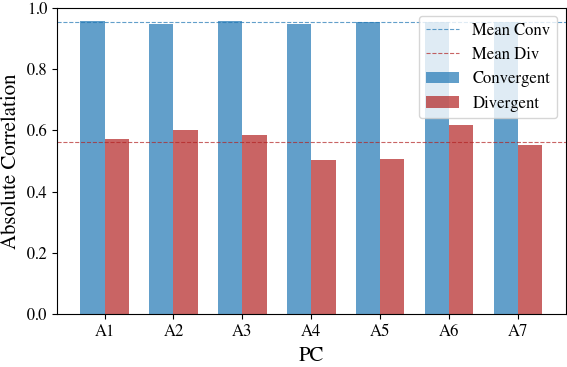

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(7)]
conv_corrs = [conv_score_1, conv_score_2, conv_score_3, conv_score_4, conv_score_5, conv_score_6, conv_score_7]
div_corrs = [div_score_1, div_score_2, div_score_3, div_score_4, div_score_5, div_score_6, div_score_7]

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Add horizontal dashed lines
ax.axhline(y=abs(sum(conv_corrs) / len(conv_corrs)), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=abs(sum(div_corrs) / len(div_corrs)), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'A{i+1}' for i in range(7)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/ability_correlations_histogram_{"".join(conv_dataset)}.pdf')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def orthogonalize_vector(vector_to_purify, reference_vector):
    """
    Purifies a vector by removing its projection onto a reference vector.
    This is a single step of the Gram-Schmidt process.

    Args:
        vector_to_purify (np.ndarray): The vector you want to purify (e.g., v_math).
        reference_vector (np.ndarray): The vector representing the component to remove (e.g., v_div).

    Returns:
        np.ndarray: The purified, orthogonal vector, normalized to unit length.
    """
    # Ensure vectors are normalized to unit length to start
    vector_to_purify = vector_to_purify / np.linalg.norm(vector_to_purify)
    reference_vector = reference_vector / np.linalg.norm(reference_vector)

    # 1. Calculate the projection of vector_to_purify onto reference_vector
    dot_product = np.dot(vector_to_purify, reference_vector)
    projection = dot_product * reference_vector
    
    # 2. Subtract the projection to get the orthogonal component
    purified_vector = vector_to_purify - projection
    
    # 3. Normalize the final vector to have a length of 1
    purified_vector_normalized = purified_vector / np.linalg.norm(purified_vector)
    
    return purified_vector_normalized

In [113]:
conv_dataset = ['math', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_math_unit = compute_scalar_ability(theta_df, a_df_math, b_series, scenario_questions, return_v_unit=True)


# --- Main Execution ---

v_math_initial = v_math_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_math_pure = orthogonalize_vector(v_math_initial, v_div_reference)

print("Purified 'Math' Vector (v_math_pure):")
print(np.round(v_math_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_math_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0):
    print("Verification successful: The new math vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
Mean unit vector:  [-0.21494706 -0.22744916 -0.23566988 -0.1679211  -0.3850087  -0.2394518
  0.04993943  0.25944665 -0.39451882 -0.04396391 -0.01316161 -0.33871678
  0.30975133  0.06780565  0.26811373 -0.26613766  0.13065511 -0.04555357
 -0.08982014]
Purified 'Math' Vector (v_math_pure):
[-0.2122 -0.2259 -0.2386 -0.1656 -0.3868 -0.2402  0.0515  0.2645 -0.3985
 -0.0483 -0.0137 -0.3357  0.3048  0.06    0.269  -0.265   0.1331 -0.0416
 -0.0851]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification successful: The new math vector is orthogonal to the divergent vector.


In [109]:
v_math_pure

array([-0.2121759 , -0.22592627, -0.2385837 , -0.16556206, -0.3867546 ,
       -0.24016796,  0.05153811,  0.26446506, -0.3984767 , -0.04828941,
       -0.01366189, -0.3356655 ,  0.30475757,  0.05998956,  0.26903284,
       -0.26501375,  0.13307221, -0.04164824, -0.08511668], dtype=float32)

In [ ]:
math_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_math_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_corr = math_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_corr)

conv_corr = math_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_corr)

Used pre-computed math direction vector. [-0.2121759  -0.22592627 -0.2385837  -0.16556206 -0.3867546  -0.24016796
  0.05153811  0.26446506 -0.3984767  -0.04828941 -0.01366189 -0.3356655
  0.30475757  0.05998956  0.26903284 -0.26501375  0.13307221 -0.04164824
 -0.08511668]
Used pre-computed math direction vector. [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
div_corr 0.05946441299256695
conv_corr 0.9578550469115413


In [135]:
conv_dataset = ['civil_comments']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_civil_unit = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, return_v_unit=True)


# --- Main Execution ---

v_civil_initial = v_civil_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_civil_pure = orthogonalize_vector(v_civil_initial, v_div_reference)

print("Purified Vector:")
print(np.round(v_civil_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_civil_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0, atol=1e-6):
    print("Verification successful: The new vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.01066437  0.0677963  -0.19088022  0.11288884 -0.13905899 -0.17810167
 -0.14930539  0.2693178  -0.32165006 -0.30804336  0.09588453 -0.22094901
  0.05280206 -0.3262895   0.28594893 -0.44817394 -0.14415763  0.23588334
  0.2748914 ]
Mean unit vector:  [ 0.20023796  0.05788276 -0.1069426   0.09518023 -0.06088974  0.05889294
  0.24028295  0.21884258 -0.10403278 -0.12189907 -0.11112836  0.38503283
 -0.4184568  -0.38032684 -0.12009979  0.4024026   0.3067861   0.13583957
  0.16821377]
Purified Vector:
[ 0.2009  0.061  -0.1157  0.1004 -0.0672  0.0509  0.2338  0.2312 -0.1187
 -0.1359 -0.1069  0.3755 -0.4165 -0.3954 -0.1073  0.3826  0.3006  0.1466
  0.1808]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification successful: The new vector is orthogonal to the divergent vector.


In [136]:
civil_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_civil_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_corr = civil_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_corr)

conv_corr = civil_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_corr)

Used pre-computed direction vector. [ 0.20092313  0.06100155 -0.11566652  0.10037216 -0.0672279   0.05091459
  0.23378894  0.23122054 -0.11865579 -0.13592616 -0.10691391  0.37545267
 -0.41649967 -0.39544052 -0.10731625  0.38258472  0.3005921   0.14662404
  0.18079177]
Used pre-computed direction vector. [ 0.01066437  0.0677963  -0.19088022  0.11288884 -0.13905899 -0.17810167
 -0.14930539  0.2693178  -0.32165006 -0.30804336  0.09588453 -0.22094901
  0.05280206 -0.3262895   0.28594893 -0.44817394 -0.14415763  0.23588334
  0.2748914 ]
div_corr -0.2210314631911211
conv_corr 0.989673853447905


In [ ]:
# Get mean scores and find common indices (models that have non-NaN values for both)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()
print(len(common_indices))
display(common_indices)
# count each company in common_indices
company_counts = {}
for model in common_indices:
    company = model.split('/')[0]
    if company not in company_counts:
        company_counts[company] = 0
    company_counts[company] += 1
print(company_counts)

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()

scores_mapping = {
    'CR': score_1,
    'ST': score_2,
    'RRP': score_3,
    'CA': score_4,
    'FP': score_5,
    'WP': score_6,
    'AF': score_7,
}

skill_scores = pd.DataFrame(scores_mapping)

skill_scores = skill_scores.loc[common_indices]

# Function to create radar chart
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    """
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize colors if not provided
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    
    # Plot each model
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]  # Complete the circle
        
        model_name = model_names[i] if model_names else f'Model {i+1}'
        # Extract just the model name after the company prefix
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.25, zorder=i + 1)
    
    # Add labels
    ax.tick_params(pad=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, weight='bold')
    ax.set_ylim(0, 4)  # Set consistent scale
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=1, color='black', zorder=10)
    
    # Ensure y-ticks align with circles
    ax.set_rgrids([1, 2, 3, 4], angle=0, labels=["1", "2", "3", "4"], fontsize=12)

    # Hide the zero label
    ax.set_rmin(0)

# Filter and group models by company
companies = {
    'meta': [],
    'openai': [], 
    'anthropic': [],
    'google': []
}

# Group models by company prefix (only include models that have all 4 skill scores)
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)
    elif model.startswith(('google/')):
        companies['google'].append(model)

# UPDATED VERSION: Select top models from each company with explicit model inclusion
def select_top_models(models, n=6, explicit_models=None):
    """
    Select top models from a list, with option to include explicit models.
    
    Args:
        models: List of model names to choose from
        n: Number of top models to select
        explicit_models: List of model names that must be included if they exist in models
        
    Returns:
        List of selected model names
    """
    if not models:
        return []
    
    # Initialize result with explicit models that exist in the models list
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    
    # If we already have enough models from explicit list, return them
    if len(result) >= n:
        return result[:n]
    
    # Get model scores and sort by performance
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    print(model_scores)
    
    # Add top performing models that aren't already in the result
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0:
                break
    
    return result

# Define explicit models to include for each company
explicit_models_by_company = {
    'openai': ['openai/text-davinci-002'],
    # Add other companies and their explicit models as needed
    # 'anthropic': ['anthropic/claude-v1'],
    # 'google': ['google/specific-model'],
    # etc.
}

# Get top models for each company with explicit model inclusion
selected_models = {
    company: select_top_models(
        models, 
        n=6, 
        explicit_models=explicit_models_by_company.get(company, [])
    ) 
    for company, models in companies.items()
}
# Create the radar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Skill labels 
skill_labels = scores_mapping.keys()

company_names = ['Meta', 'OpenAI', 'Anthropic', 'Google']
company_keys = ['meta', 'openai', 'anthropic', 'google']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        # Get data for selected models using skill scores
        model_data = skill_scores.loc[models].values
        
        # Create color palette for this company
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'google':
            colors = plt.cm.Greens_r(np.linspace(0.1, 0.9, len(models)))
        create_radar_chart(model_data, skill_labels, company_name, axes[i], 
                         colors=colors, model_names=models)
        
        # Add legend with abbreviated names
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_math_skill_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of selected models and their scores
print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        scores = skill_scores.loc[model]
        print(f"  {model}")